In [ ]:
from datascience import *
from datascience.predicates import are
path_data = '../../../../data/'
import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen
import re
def read_url(url):
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

# Plotting the classics

In this example, we will explore statistics for two classic novels: *The Adventures of Huckleberry Finn* by Mark Twain, and *Little Women* by Louisa May Alcott. The text of any book can be read by a computer at great speed. Books published before 1923 are currently in the *public domain*, meaning that everyone has the right to copy or use the text in any way. [Project Gutenberg](http://www.gutenberg.org/) is a website that publishes public domain books online. Using Python, we can load the text of these books directly from the web.

This example is meant to illustrate some of the broad themes of this text. Don't worry if the details of the program don't yet make sense. Instead, focus on interpreting the images generated below. Later sections of the text will describe most of the features of the Python programming language used below.

First, we read the text of both books into lists of chapters, called `huck_finn_chapters` and `little_women_chapters`. In Python, a name cannot contain any spaces, and so we will often use an underscore `_` to stand in for a space. The `=` in the lines below give a name on the left to the result of some computation described on the right. A *uniform resource locator* or *URL* is an address on the Internet for some content; in this case, the text of a book. The `#` symbol starts a comment, which is ignored by the computer but helpful for people reading the code.

In [ ]:
# Read three books, fast!

huck_finn_url = 'https://www.gutenberg.org/cache/epub/76/pg76.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split('CHAPTER ')[44:]

little_women_url = 'https://www.gutenberg.org/cache/epub/514/pg514.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[48:]

moby_dick_url = 'https://www.gutenberg.org/cache/epub/2701/pg2701.txt'
mody_dick_text = read_url(moby_dick_url)
moby_dick_chapters = moby_dick_text.split('CHAPTER ')[136:]

While a computer cannot understand the text of a book, it can provide us with some insight into the structure of the text. The name `huck_finn_chapters` is currently bound to a list of all the chapters in the book. We can place them into a table to see how each chapter begins.

In [ ]:
# Display the chapters of Huckleberry Finn in a table.

Table().with_column('Chapters', huck_finn_chapters)

Chapters
I. You don’t know about me without you have read a book ...
II. We went tiptoeing along a path amongst the trees bac ...
"III. Well, I got a good going-over in the morning from o ..."
"IV. Well, three or four months run along, and it was wel ..."
V. I had shut the door to. Then I turned around and ther ...
"VI. Well, pretty soon the old man was up and around agai ..."
VII. “Git up! What you ’bout?” I opened my eyes and look ...
VIII. The sun was up so high when I waked that I judged ...
IX. I wanted to go and look at a place right about the m ...
X. After breakfast I wanted to talk about the dead man a ...


Each chapter begins with a chapter number in Roman numerals, followed by the first sentence of the chapter. Project Gutenberg has printed the first word of each chapter in upper case.

In [ ]:
# The chapters of Little Women, in a table

Table().with_column('Chapters', little_women_chapters)

Chapters
ONE PLAYING PILGRIMS “Christmas won’t be Christmas witho ...
TWO A MERRY CHRISTMAS Jo was the first to wake in the gr ...
THREE THE LAURENCE BOY “Jo! Jo! Where are you?” cried Me ...
"FOUR BURDENS “Oh, dear, how hard it does seem to take up ..."
FIVE BEING NEIGHBORLY “What in the world are you going t ...
SIX BETH FINDS THE PALACE BEAUTIFUL The big house did pr ...
SEVEN AMY’S VALLEY OF HUMILIATION “That boy is a perfect ...
"EIGHT JO MEETS APOLLYON “Girls, where are you going?” as ..."
NINE MEG GOES TO VANITY FAIR “I do think it was the most ...
"TEN THE P.C. AND P.O. As spring came on, a new set of am ..."


In [ ]:
# The chapters of Moby Dick, in a table

Table().with_column('Chapters', moby_dick_chapters)

Chapters
1. Loomings. Call me Ishmael. Some years ago—never mind ...
2. The Carpet-Bag. I stuffed a shirt or two into my old ...
3. The Spouter-Inn. Entering that gable-ended Spouter-In ...
4. The Counterpane. Upon waking next morning about dayli ...
"5. Breakfast. I quickly followed suit, and descending in ..."
6. The Street. If I had been astonished at first catchin ...
7. The Chapel. In this same New Bedford there stands a W ...
8. The Pulpit. I had not been seated very long ere a man ...
"9. The Sermon. Father Mapple rose, and in a mild voice o ..."
10. A Bosom Friend. Returning to the Spouter-Inn from th ...


# Literary Characters

Text(0.5, 1.08, 'Cumulative Number of Times Each Name Appears')

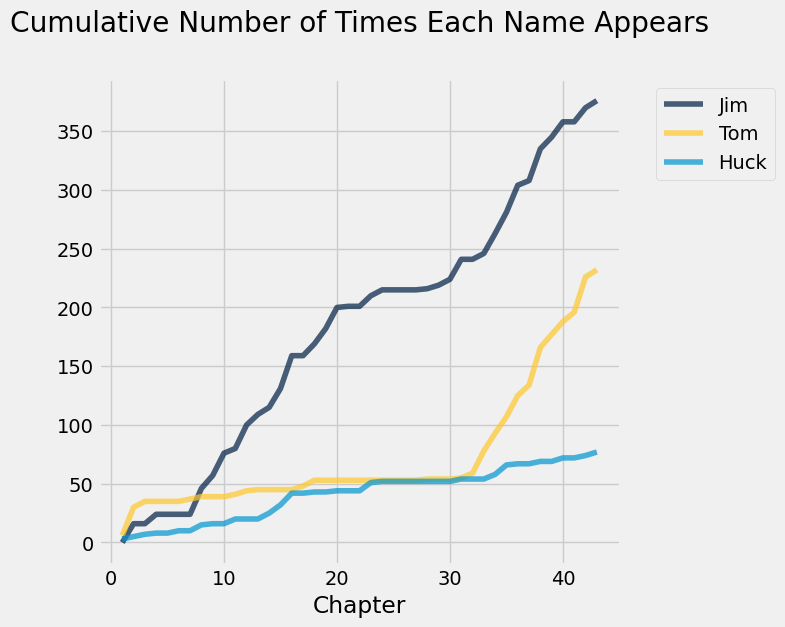

In [ ]:
# Get the cumulative counts the names Jim, Tom, and Huck appear in each chapter.

counts = Table().with_columns([
        'Jim', np.cumsum(np.char.count(huck_finn_chapters, 'Jim')),
        'Tom', np.cumsum(np.char.count(huck_finn_chapters, 'Tom')),
        'Huck', np.cumsum(np.char.count(huck_finn_chapters, 'Huck'))
    ])

# Plot the cumulative counts:
# how many times in Chapter 1, how many times in Chapters 1 and 2, and so on.

cum_counts = counts.with_column('Chapter', np.arange(1, 44, 1))
cum_counts.plot(column_for_xticks=3)
plots.title('Cumulative Number of Times Each Name Appears', y=1.08)

Text(0.5, 1.08, 'Cumulative Number of Times Each Name Appears')

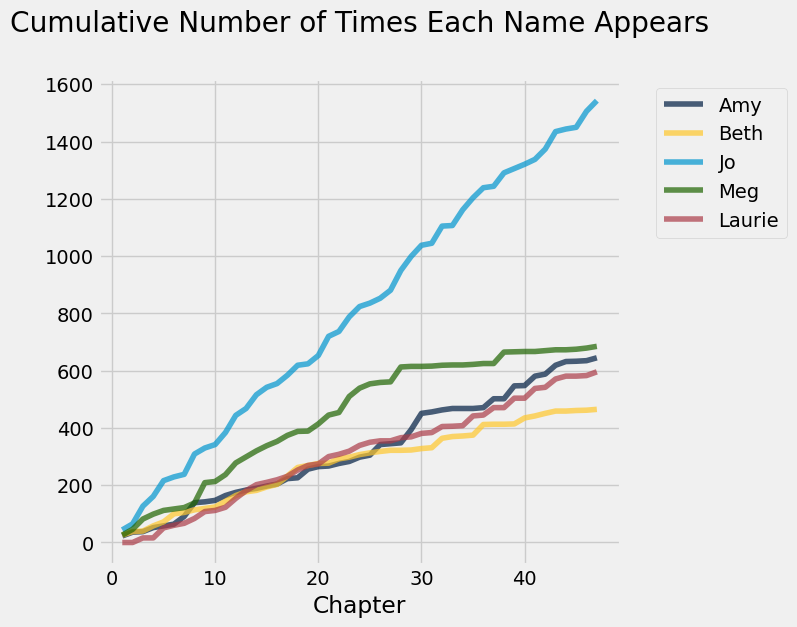

In [ ]:
# Get the cumulative counts of the names in the chapters of Little Women

counts = Table().with_columns([
        'Amy', np.cumsum(np.char.count(little_women_chapters, 'Amy')),
        'Beth', np.cumsum(np.char.count(little_women_chapters, 'Beth')),
        'Jo', np.cumsum(np.char.count(little_women_chapters, 'Jo')),
        'Meg', np.cumsum(np.char.count(little_women_chapters, 'Meg')),
        'Laurie', np.cumsum(np.char.count(little_women_chapters, 'Laurie')),

    ])

# Plot the cumulative counts.

cum_counts = counts.with_column('Chapter', np.arange(1, 48, 1))
cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Each Name Appears', y=1.08)

Text(0.5, 1.08, 'Cumulative Number of Times Each Name Appears')

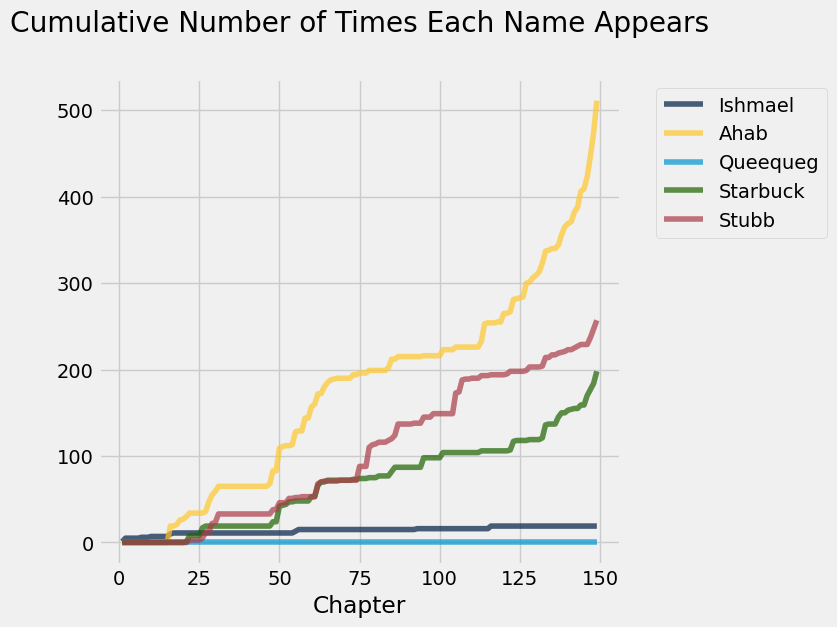

In [ ]:
# Get the cumulative counts of the names in the chapters of Moby Dick

counts = Table().with_columns([
        'Ishmael', np.cumsum(np.char.count(moby_dick_chapters, 'Ishmael')),
        'Ahab', np.cumsum(np.char.count(moby_dick_chapters, 'Ahab')),
        'Queequeg', np.cumsum(np.char.count(moby_dick_chapters, 'QueeQueg')),
        'Starbuck', np.cumsum(np.char.count(moby_dick_chapters, 'Starbuck')),
        'Stubb', np.cumsum(np.char.count(moby_dick_chapters, 'Stubb')),

    ])

# Plot the cumulative counts.
# Get the correct number of chapters
num_chapters = len(moby_dick_chapters)

# Use num_chapters to create the 'Chapter' column
cum_counts = counts.with_column('Chapter', np.arange(1, num_chapters + 1, 1))
cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Each Name Appears', y=1.08)

For my book of choice, Moby Dick, the graph above shows how that the names "Ishmael" and "Queequeg" are barely mentioned throughout the book even though they are two very important characters in the story, one even being the story's narrator. In contrast, the amount of times the name "Ahab" is mentioned seems to exponentially increase, especially towards the end of the book during the last chapters.

# Another Kind of Character

In [ ]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

chars_periods_huck_finn = Table().with_columns([
        'Huck Finn Chapter Length', [len(s) for s in huck_finn_chapters],
        'Number of Periods', np.char.count(huck_finn_chapters, '.')
    ])
chars_periods_little_women = Table().with_columns([
        'Little Women Chapter Length', [len(s) for s in little_women_chapters],
        'Number of Periods', np.char.count(little_women_chapters, '.')
    ])
chars_periods_moby_dick = Table().with_columns([
        'Moby Dick Chapter Length', [len(s) for s in moby_dick_chapters],
        'Number of Periods', np.char.count(moby_dick_chapters, '.')
    ])

In [ ]:
chars_periods_huck_finn

Huck Finn Chapter Length,Number of Periods
7018,66
11972,117
8522,72
6794,84
8147,91
14524,125
13204,127
22189,249
8069,71
7036,70


In [ ]:
chars_periods_little_women

Little Women Chapter Length,Number of Periods
21757,189
22148,188
20558,231
25524,195
23396,255
14621,140
14430,131
22476,214
33765,337
18333,185


In [ ]:
chars_periods_moby_dick

Moby Dick Chapter Length,Number of Periods
12187,82
7920,47
31929,229
9112,53
4181,28
4801,41
5368,38
5397,29
19672,120
8692,63


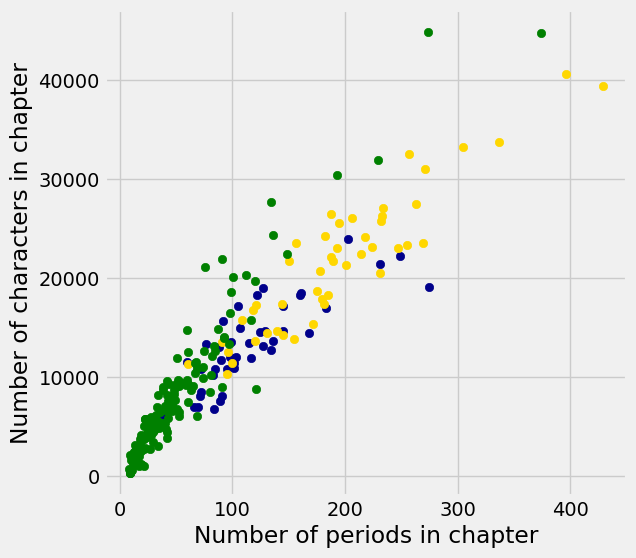

In [ ]:
plots.figure(figsize=(6, 6))
plots.scatter(chars_periods_huck_finn.column(1),
              chars_periods_huck_finn.column(0),
              color='darkblue')
plots.scatter(chars_periods_little_women.column(1),
              chars_periods_little_women.column(0),
              color='gold')
plots.scatter(chars_periods_moby_dick.column(1),
              chars_periods_moby_dick.column(0),
              color='green')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');